In [1]:
from xaikd import datasets, models, utils, constants, attributors

from torch.utils.data import random_split, DataLoader

from torchvision.datasets import CIFAR100
from torchmetrics.classification import BinaryAUROC

from torch.nn import functional as F

import pandas as pd
import torch
import numpy as np 
import numpy.typing as npt

from tqdm.notebook import tqdm
from torch import nn

from datetime import datetime

from matplotlib import pyplot as plt

import matplotlib as mpl

from scipy.stats import norm as norm_gaussian

In [2]:
pd.read_csv(constants.CIFAR100_SUPER_CLASS_MAPPING)["coarse_label_name"].unique()

array(['aquatic_mammals', 'food_containers', 'small_mammals',
       'large_natural_outdoor_scenes', 'large_carnivores', 'vehicles_1',
       'people', 'flowers', 'medium_mammals', 'reptiles',
       'large_omnivores_and_herbivores', 'fruit_and_vegetables', 'trees',
       'household_furniture', 'vehicles_2', 'fish',
       'household_electrical_devices', 'large_man_made_outdoor_things',
       'insects', 'non_insect_invertebrates'], dtype=object)

In [3]:
DEVICE = utils.get_device()

DEVICE

DATA_SIZE = 0.1


# SELECTED_GROUP = "aquatic_mammals"
SELECTED_GROUP = "people"

In [4]:
dataset = datasets.construct("cifar100")

In [5]:
def get_fine_labels(name):

    if "class" in name:
        label = int(name.replace("class", ""))
        return [label]
    df = pd.read_csv(constants.CIFAR100_SUPER_CLASS_MAPPING)
    return sorted(df[df.coarse_label_name == name].fine_label.values)
SELECTED_CLASSES = get_fine_labels(SELECTED_GROUP)
SELECTED_CLASSES

[2, 11, 35, 46, 98]

In [6]:
NOT_SELECTED_CLASSES = sorted(set(np.arange(100)).difference(SELECTED_CLASSES))

In [7]:
NOT_SELECTED_CLASSES

[0,
 1,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 99]

In [8]:
def target_transform(label):
    if label in SELECTED_CLASSES:
        return 1
    else:
        return 0

In [9]:
trng = torch.Generator()
trng.manual_seed(1)

transform = datasets.construct("cifar100").input_transformation
ds_train = CIFAR100(root="/datasets/cifar100", download=False, train=True, transform=transform, target_transform=target_transform)
ds_train, _ = random_split(ds_train, [DATA_SIZE, 1-DATA_SIZE])

ds_val = CIFAR100(root="/datasets/cifar100", download=False, train=False, transform=transform,  target_transform=target_transform)

dl_train = DataLoader(ds_train, num_workers=12, shuffle=False, batch_size=128)
dl_val = DataLoader(ds_val, num_workers=12, shuffle=False,  batch_size=128)

In [10]:
def ano():
    for label, dl in [
        ("train", dl_train),
        ("val", dl_val),
    ]:
        arr_values = []
        for _, y in tqdm(dl):
            arr_values.extend(y.tolist())
        print(f"[subset={label}] p(y=1)={np.mean(arr_values):.4f}")
ano()

  0%|          | 0/40 [00:00<?, ?it/s]

[subset=train] p(y=1)=0.0526


  0%|          | 0/79 [00:00<?, ?it/s]

[subset=val] p(y=1)=0.0500


In [11]:
class LastLayerBinary(nn.Module):
    def __init__(self, fc):
        super().__init__()
        self.fc = fc

    def forward(self, x):
        logits = self.fc(x)
        lse_pos = torch.logsumexp(logits[:, SELECTED_CLASSES], dim=1)
        lse_neg = torch.logsumexp(logits[:, NOT_SELECTED_CLASSES], dim=1)
        return lse_pos - lse_neg
        

def construct_model():
    model = models.get_trained_model("cifar100-resnet18-v1")

    model.fc = LastLayerBinary(model.fc)
    model.eval()
    model.to(DEVICE)
    
    return model

def sanity_check():
    
    model  = construct_model()

    output = model(torch.randn((5, 3, 32, 32)).to(DEVICE))
    assert output.shape == (5,)
    print("[Sanity check passed]: Model is callable")
    
sanity_check()

[Sanity check passed]: Model is callable


In [12]:
model = construct_model()
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

In [13]:
def compute_performance(model, verbose=False):
    dl =  dl_val
    metric = BinaryAUROC(thresholds=20)
    model.to(DEVICE)

    for x, y in tqdm(dl, disable=not verbose):
        x = x.to(DEVICE)
        logit = model(x).cpu()
        
        metric.update(logit, y)

    metric = float(metric.compute())
    metric = np.max([metric, 1-metric])
    return metric
    
ref_performance = compute_performance(model, verbose=True)    
ref_performance

  0%|          | 0/79 [00:00<?, ?it/s]

0.9878010153770447

In [14]:
def extract_logits(model, dl, verbose=False):
    arr_logits = []
    for x, y in tqdm(dl, disable=not verbose, desc="Extract Logits"):
        x = x.to(DEVICE)
        logits = model(x).detach().cpu().numpy()
        arr_logits.extend(logits.tolist())
    return np.array(arr_logits)
    
extract_logits(model, dl_train)

array([-10.32878017,  -9.56459141,  -7.75367498, ...,  -7.91118145,
       -11.92818165,  -9.90688801])

  0%|          | 0/40 [00:00<?, ?it/s]

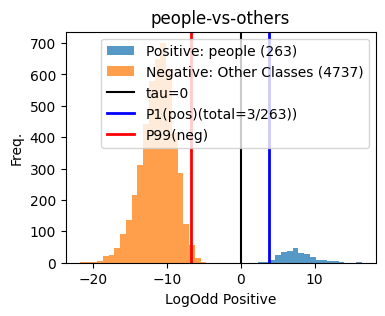

In [15]:
def compute_logit_distribution(model, verbose=False):
    dl =  dl_train

    arr_logits = []
    arr_y = []
    for x, y in tqdm(dl, disable=not verbose):
        x = x.to(DEVICE)
        logit = model(x).cpu()
        y_pred = logit > 0

        arr_y.extend(y_pred.detach().numpy().tolist())
        # arr_y.extend(y.detach().numpy().tolist())
        
        arr_logits.extend(logit.detach().numpy().tolist())

    arr_logits = np.array(arr_logits) 
    arr_y = np.array(arr_y)
    plt.figure(figsize=(4, 3))
    vmin, vmax = np.min(arr_logits), np.max(arr_logits)
    bins = np.linspace(vmin, vmax, 50)

    plt.title(f"{SELECTED_GROUP}-vs-others")
    plt.hist( 
        arr_logits[arr_y == 1],
        bins=bins,
        label=f"Positive: {SELECTED_GROUP} ({np.sum(arr_y==1)})",
        alpha=0.75
    )
    plt.hist(
        arr_logits[arr_y == 0],
        bins=bins,
        label=f"Negative: Other Classes ({np.sum(arr_y==0)})",
        alpha=0.75
    )
    
    tau = 0
    plt.axvline(tau, label=f"tau={tau}", color="black")

    perc_pos_value = 1
    
    perc_pos = np.percentile(arr_logits[arr_y==1], perc_pos_value)
    
    plt.axvline(
        perc_pos,
        label=f"P{perc_pos_value}(pos)(total={np.sum(arr_logits[arr_y==1] < perc_pos).sum()}/{(arr_y==1).sum()}))",
        lw=2,
        color="blue"
    )
    perc_neg_value = 100 - perc_pos_value

    perc_neg = np.percentile(arr_logits[arr_y==0], perc_neg_value)
    plt.axvline(
        perc_neg,
        label=f"P{perc_neg_value}(neg)",
        lw=2,
        color="red"
    )
    plt.ylabel("Freq.")
    plt.xlabel(f"LogOdd Positive")
    plt.legend()
    
compute_logit_distribution(model, verbose=True)    

In [16]:
ds_val.transforms.transform.transforms[1].mean

(0.5070751592371323, 0.48654887331495095, 0.4409178433670343)

In [17]:
def revert_transform(x):
    normalizer = ds_val.transforms.transform.transforms[1]
    mean = np.array(normalizer.mean).reshape((1, 1, 1, 3))
    std = np.array(normalizer.std).reshape((1, 1, 1, 3))
    x =  x * std + mean
    x = np.clip(x, a_min=0, a_max=1)
    return x

  0%|          | 0/40 [00:00<?, ?it/s]

(5000, 32, 32, 3)


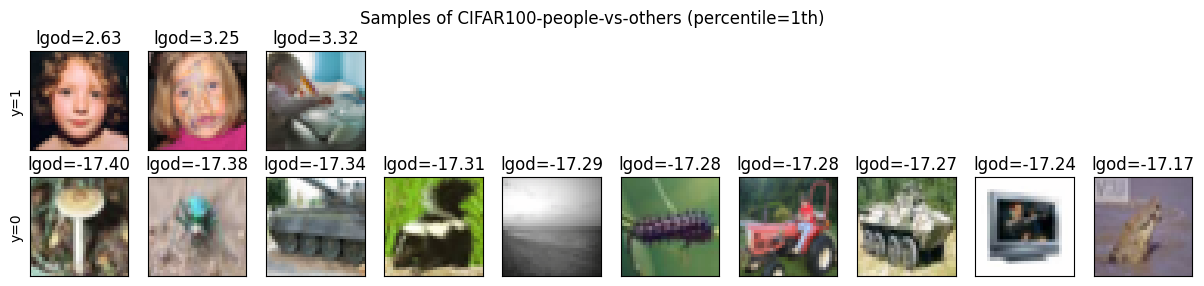

In [32]:
def viz_support_samples():
    percentile = 1

    arr_x = []
    arr_logits = []
    arr_y = []
    for x, y in tqdm(dl_train):
        
        x = x.to(DEVICE)
        logit = model(x).cpu()
        y_pred = logit > 0

        arr_y.extend(y_pred.detach().numpy().tolist())
        # arr_y.extend(y.detach().numpy().tolist())
        arr_x.append(x.permute(0, 2, 3, 1).cpu().numpy())
        arr_logits.extend(logit.detach().numpy().tolist())
        
    arr_logits = np.array(arr_logits) 
    arr_y = np.array(arr_y)
    arr_x = revert_transform(np.vstack(arr_x))
    print(arr_x.shape)

    
    perc_pos_value = 1
    
    perc_pos = np.percentile(arr_logits[arr_y==1], perc_pos_value)
    
    perc_neg = np.percentile(arr_logits[arr_y==0], perc_pos_value)

    ncols = 10
    nrows = 2

    plt.figure(figsize=(1.5*ncols, 1.5*nrows))
    plt.suptitle(f"Samples of CIFAR100-{SELECTED_GROUP}-vs-others (percentile={percentile}th)", y=1.01)
    
    for lix, label in enumerate([1, 0]):
        selected =  (arr_logits >= perc_neg)*(arr_logits <= perc_pos) * (arr_y == label)

        _x = arr_x[selected, :, :, :]
        _logodd = arr_logits[selected]

        sorted_indices = np.argsort(_logodd)
        
        
        for cix, six in enumerate(sorted_indices[:ncols]):
            if cix > _x.shape[0] - 1:
                break
            
            plt.subplot(nrows, ncols, lix * ncols + cix + 1)
            plt.imshow(_x[six, :, :])
            plt.xticks([]); plt.yticks([])
            plt.title(f"lgod={_logodd[six]:.2f}")
            if cix == 0:
                plt.ylabel(f"y={label}")
            
viz_support_samples()

# Extract Activation

## Output Quantities

In [19]:
class OutputQuantity:
    def __call__(self, logits, target_logits):
        raise NotImplementedError()
    def __str__(self):
        return self.__class__.__name__
        
class LogOddWinningClass(OutputQuantity):
    def __call__(self, logits, targets):
        return torch.sign(logits).detach() * logits

        
class LogOddClass(OutputQuantity):
    def __call__(self, logits, targets):
        return logits

## Sample Selection Critieria

In [20]:
XXX = [1,2, 5,0]
XXX[-2:]

[5, 0]

In [21]:
# class CriteriaSampleSelection:
#     def __call__(self, logits: torch.Tensor):
#         raise NotImplementedError("error")
#     def slug(self) -> str:
#         raise NotImplementedError("error")
# class CriteriaSelectNSamples(CriteriaSampleSelection):
    
#     def __init__(self, N: int, threshold=0, verbose=False):
#         self.N = N
        
#         arr_logits = extract_logits(model, dl=dl_train, verbose=verbose)
#         self.total = arr_logits.shape[0]
        
#         is_in_left_region = arr_logits < threshold
#         is_in_right_region = arr_logits >= threshold


#         self.criteria_left = np.sort(arr_logits[is_in_left_region])[-N]
#         self.criteria_right = np.sort(arr_logits[is_in_right_region])[N]
        

#     def __call__(self, logits):
#         return (logits > self.criteria_left) * (logits <= self.criteria_right)
        
#     def __str__(self):
#         return f"SelectNSamples(N={self.N}, total={self.total}, [{self.criteria_left:.2f}, {self.criteria_right:.2f}])"
#     def slug(self):
#         return f"select-{self.N}"

# class CriteriaSelectNSamplesOppositeSide(CriteriaSampleSelection):
    
#     def __init__(self, N: int, threshold=0, verbose=False):
#         self.N = N
        
#         arr_logits = extract_logits(model, dl=dl_train, verbose=verbose)
#         self.total = arr_logits.shape[0]
        
#         is_in_left_region = arr_logits < threshold
#         is_in_right_region = arr_logits >= threshold


#         self.criteria_left = np.sort(arr_logits[is_in_left_region])[N]
#         self.criteria_right = np.sort(arr_logits[is_in_right_region])[-N]
        

#     def __call__(self, logits):
#         return torch.logical_or(
#             (logits < self.criteria_left),
#             (logits >= self.criteria_right)
#         )
        
#     def __str__(self):
#         return f"SelectNSamplesOppositeSide(N={self.N}, total={self.total}, [{self.criteria_left:.2f}, {self.criteria_right:.2f}])"
#     def slug(self):
#         return f"select-opposite-side-{self.N}"
        
# class CriteriaSelectAllSamples(CriteriaSampleSelection):
#     def __call__(self, logits):
#         return torch.ones_like(logits).int().to(logits.device)
        
#     def __str__(self):
#         return f"SelectNSamples(N=∞)"

#     def slug(self):
#         return f"select-all"
    
# def ano():
#     arr_logits = extract_logits(model, dl=dl_train, verbose=True)

#     arr_logits = torch.from_numpy(arr_logits)
    
#     for N in [5, 10, 100]:
        
#         criteria = CriteriaSelectNSamples(N=N)
    
#         np.testing.assert_allclose(
#             criteria(arr_logits).sum(),
#             2*N
#         )
#         print(f"sanity check: {criteria} passed!")

#     all_cri = CriteriaSelectAllSamples()
#     all_cri(arr_logits)
#     print(f"sanity check: {all_cri} passed!")

#     print(f"sanity check: {CriteriaSelectNSamplesOppositeSide(N=10)(arr_logits)} passed!")
# ano()

In [22]:
def subsample_tensors(
    act,
    ctx,
    rng,
    num_locations=20,
):
    assert len(act.shape) == 4

    bs, nc, h, w = act.shape

    total_spatial_locations = w * h
    arr_act = []
    arr_ctx = []

    for ix in range(bs):
        _a = act[ix]
        _c = ctx[ix]

        assert _a.shape == (nc, h, w)

        selected = rng.permutation(total_spatial_locations)[:num_locations]
        flattened_act = _a.reshape((nc, -1))
        flattened_ctx = _c.reshape((nc, -1))
        selected_act = flattened_act[:, selected]
        selected_ctx = flattened_ctx[:, selected]
        
        arr_act.append(selected_act[np.newaxis, :, :])
        arr_ctx.append(selected_ctx[np.newaxis, :, :])

    arr_act = np.vstack(arr_act)
    arr_ctx = np.vstack(arr_ctx)

    assert arr_act.shape == (bs, nc, np.min([num_locations, total_spatial_locations]))

    return arr_act, arr_ctx

In [23]:
def extract_activation_context_for_task(
    model: nn.Module,
    layer: str,
    data_loader=dl_train,
    seed=1,
    device=DEVICE,
    number_of_selected_spatial_locations=20,
    strict_mode=False,
    verbose=False
):

    arr_logodds = []
    arr_act = []
    arr_ctx = []

    rng = np.random.default_rng(seed=1)
    logodd_quantity = LogOddWinningClass()

    try:
        
        module, hook = utils.interceptor.attach_hook_intercept_layer_output(
            model, layer, should_retain_grad=True, detach_output=False
        )

        
        for batch in tqdm(data_loader, desc=f"[layer={layer}] extract actctx (group={SELECTED_GROUP}"):
            x, y = batch
            x = x.to(device)


            logits = model(x)

            (logodd_quantity(logits, y)).sum().backward()
            
            act = utils.interceptor.get_output(module)

            assert act.grad is not None
            ctx = act.grad
            
            output_dimensions = act.shape[1:]

            assert ctx.shape == act.shape
            
            act = act.detach().cpu().numpy()
            ctx = ctx.detach().cpu().numpy()
        
            selected_act, selected_ctx = subsample_tensors(
                act,
                ctx,
                num_locations=number_of_selected_spatial_locations,
                rng=rng,
            )
            
            arr_logodds.extend(logits.detach().cpu().numpy().tolist())
            arr_act.append(selected_act)
            arr_ctx.append(selected_ctx)

    finally:
        hook.remove()
        model.fc.task_id = None

    print(f"{layer}: output-dims={output_dimensions}")

    arr_act = np.vstack(arr_act)

    print(f"arr_act.shape={arr_act.shape}")
    
    arr_ctx = np.vstack(arr_ctx)
    arr_logodds = np.array(arr_logodds)

    print(f"arr_logodds.shape={arr_logodds.shape}")
    
    
    return arr_logodds, arr_act, arr_ctx


def ano():

    arr_logodds, arr_act, arr_ctx = extract_activation_context_for_task(
        model, 
        "layer1",
        data_loader=dl_train,
    )

    print(np.bincount(arr_logodds > 0))

ano()

[layer=layer1] extract actctx (group=people:   0%|          | 0/40 [00:00<?, ?it/s]

layer1: output-dims=torch.Size([64, 32, 32])
arr_act.shape=(5000, 64, 20)
arr_logodds.shape=(5000,)
[4737  263]


# Construct Basis

In [24]:
def _solve_eigvecs(cov, sort_func=lambda x: x):
    eigvals, eigvecs = np.linalg.eigh(cov)

    assert len(eigvals.shape) == 1

    indices = np.argsort(-sort_func(eigvals))
    eigvals = eigvals[indices]
    eigvecs = eigvecs[:, indices]

    return eigvecs, sort_func(eigvals)

def flatten_array(x):
    # x.shape == (bs, nc, spatial)

    bs, nc, num_spatials = x.shape
    
    x = np.transpose(x, [1, 0, 2])
    x = x.reshape((nc, bs * num_spatials))
    x = x.T
    return x
    

class BasisInterface:
    def get_Uk(self, k: int):
        return self.U[:, :k]

class PCA(BasisInterface):
    def __init__(self, arr_logodd, arr_act, arr_ctx):

        arr_act = flatten_array(arr_act)
        
        N, d = arr_act.shape
        cov = arr_act.T @ arr_act / N
        self.cov = cov
        self.U, self.eigvals = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

class GradPCA(BasisInterface):
    def __init__(self, arr_logodd, arr_act, arr_ctx):

        arr_ctx = flatten_array(arr_ctx)

        N, d = arr_ctx.shape
        
        cov = arr_ctx.T @ arr_ctx / N
        
        self.cov = cov
        self.U, self.eigvals = _solve_eigvecs(cov)

class GradPCAWeightSTDFromP0_1(BasisInterface):
    percentile = 0.1
    
    def __init__(self, arr_logodd, arr_act, arr_ctx):
        y_pred = arr_logodd > 0

        
        assert self.percentile is not None
        
        perc_pos = np.percentile(arr_logodd[y_pred == 1], self.percentile)
        perc_neg = np.percentile(arr_logodd[y_pred == 0], 100-self.percentile)
        
        assert perc_pos > perc_neg

        std = 0.5*(perc_pos - perc_neg)
        
        weights = norm_gaussian.pdf(
            arr_logodd, 
            loc=0, # todo: this should synchonize with threshold computing logodd 
            scale=std
        )

        weights = weights/np.sum(weights)

        arr_ctx = arr_ctx * weights.reshape((-1, 1, 1))
        
        
        arr_ctx = flatten_array(arr_ctx)

        N, d = arr_ctx.shape
        
        cov = arr_ctx.T @ arr_ctx / N
        
        self.cov = cov
        self.U, self.eigvals = _solve_eigvecs(cov)


class PRCAPosDef(BasisInterface):
    def __init__(self, arr_logodd, arr_act, arr_ctx):

        arr_act = flatten_array(arr_act)
        arr_ctx = flatten_array(arr_ctx)

        
        cov_a = arr_act.T @ arr_act
        cov_c = arr_ctx.T @ arr_ctx

        cov_ac = arr_act.T @ arr_ctx
        cov_acca = cov_ac + cov_ac.T

        tr_cov_a = np.trace(cov_a)
        tr_cov_c = np.trace(cov_c)
        
        cov =  (1/np.sqrt(tr_cov_a*tr_cov_c)) * cov_ac \
            + (2/tr_cov_a)*cov_a \
            + (2/tr_cov_c)*cov_c
        
        self.U, self.eigvals = _solve_eigvecs(cov)

class PRCAPosDefWeightSTDWithPercentile(BasisInterface):
    percentile = None
    
    def __init__(self, arr_logodd, arr_act, arr_ctx):

        y_pred = arr_logodd > 0

        assert self.percentile is not None
        
        perc_pos = np.percentile(arr_logodd[y_pred == 1], self.percentile)
        perc_neg = np.percentile(arr_logodd[y_pred == 0], 100-self.percentile)
        
        assert perc_pos > perc_neg

        std = 0.5*(perc_pos - perc_neg)
        
        weights = norm_gaussian.pdf(
            arr_logodd, 
            loc=0, # todo: this should synchonize with threshold computing logodd 
            scale=std
        )

        weights = weights/np.sum(weights)

        arr_ctx = arr_ctx * weights.reshape((-1, 1, 1))
        
        
        arr_act = flatten_array(arr_act)
        arr_ctx = flatten_array(arr_ctx)

        
        cov_a = arr_act.T @ arr_act
        cov_c = arr_ctx.T @ arr_ctx

        cov_ac = arr_act.T @ arr_ctx
        cov_acca = cov_ac + cov_ac.T

        tr_cov_a = np.trace(cov_a)
        tr_cov_c = np.trace(cov_c)
        
        cov =  (1/np.sqrt(tr_cov_a*tr_cov_c)) * cov_ac \
            + (2/tr_cov_a)*cov_a \
            + (2/tr_cov_c)*cov_c
        
        self.U, self.eigvals = _solve_eigvecs(cov)



class PRCAPosDefWeightSTDFromP0_001(PRCAPosDefWeightSTDWithPercentile):
    percentile = 0.001


class PRCAPosDefWeightSTDFromP0_01(PRCAPosDefWeightSTDWithPercentile):
    percentile = 0.01

class PRCAPosDefWeightSTDFromP0_1(PRCAPosDefWeightSTDWithPercentile):
    percentile = 0.1

class PRCAPosDefWeightSTDFromP1(PRCAPosDefWeightSTDWithPercentile):
    percentile = 1

class PRCAPosDefWeightSTDFromP5(PRCAPosDefWeightSTDWithPercentile):
    percentile = 5


class PRCAPosDefWeightSTDFromP10(PRCAPosDefWeightSTDWithPercentile):
    percentile = 10


class PRCAPosDefWeightSTDFromP50(PRCAPosDefWeightSTDWithPercentile):
    percentile = 50


class PRCAPosDefWeightSTDFromP90(PRCAPosDefWeightSTDWithPercentile):
    percentile = 90

class PRCAPosDefWeightSTDFromP95(PRCAPosDefWeightSTDWithPercentile):
    percentile = 95

# Estimate Performance

In [25]:
def construct_fh(Uk):
    def fh(mod, inp, outp):
        return F.conv2d(
            outp,
            (Uk@Uk.T).unsqueeze(2).unsqueeze(3)
        )
    return fh

def compute_task_aurocs_at_k(
    model, layer, 
    arr_ks,
    arr_basis_names=[
        PCA
    ],
    
):
    arr_logodd, arr_act, arr_ctx = extract_activation_context_for_task(
        model=model, 
        layer=layer, 
    )
    
    module = getattr(model, layer)

    arr_dfs = []
    for basis_class in arr_basis_names:
        arr_stat_rows = []

        basis: BasisInterface = basis_class(
            arr_logodd=arr_logodd,
            arr_act=arr_act, 
            arr_ctx=arr_ctx,
        )
        basis_name = basis_class.__name__

        for k in tqdm(
            arr_ks,
            desc=f"[{basis_name:>20s}] Estimating Performance"
        ):
        
            if ("-k" in basis_name) and not f"{k}" == basis_name.split("k")[1]:
                continue

            Uk = basis.get_Uk(k=k)

            row = dict(
                data_group=SELECTED_GROUP,
                layer=layer,
                k=k,
                basis_name=basis_name,
            )

            Uk = torch.from_numpy(Uk).float().to(DEVICE)

            arr_hooks = []
            try:
                hook = module.register_forward_hook(construct_fh(Uk))
                arr_hooks.append(hook)
    
                for label, dl in [
                    # ("train", dl_train),
                    ("val", dl_val)
                ]:
                    row[f"{label}_auroc"] = compute_performance(model)
                
            finally:
                for hook in arr_hooks:
                    hook.remove()

            if hasattr(basis, "is_slow"):
                print(f"k={k}", row)
            arr_stat_rows.append(row)
            
     
        df = pd.DataFrame(arr_stat_rows)

        arr_dfs.append(df)

    df = pd.concat(arr_dfs).sort_values(by=["k", f"val_auroc"], ascending=[True, False])
    
    return df

compute_task_aurocs_at_k(
    model, layer="layer1", 
    arr_basis_names=[
        # PRCAPosDefWeightSTDFromP0_001,
        # PRCAPosDefWeightSTDFromP0_01,
        PRCAPosDefWeightSTDFromP0_1,
        GradPCAWeightSTDFromP0_1
        
        # PRCAPosDefWeightSTDFromP1,
        # PRCAPosDefWeightSTDFromP50,
        # PRCAPosDefWeightSTDFromP95,
        # # PCA,
        # # GradPCA,     
        # PRCAPosDef,
    ],
    arr_ks=[1, 5, 20],
)

[layer=layer1] extract actctx (group=people:   0%|          | 0/40 [00:00<?, ?it/s]

layer1: output-dims=torch.Size([64, 32, 32])
arr_act.shape=(5000, 64, 20)
arr_logodds.shape=(5000,)


[PRCAPosDefWeightSTDFromP0_1] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

[GradPCAWeightSTDFromP0_1] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

,data_group,layer,k,basis_name,val_auroc
0,people,layer1,1,GradPCAWeightSTDFromP0_1,0.501895
0,people,layer1,1,PRCAPosDefWeightSTDFromP0_1,0.500000
1,people,layer1,5,PRCAPosDefWeightSTDFromP0_1,0.820507
1,people,layer1,5,GradPCAWeightSTDFromP0_1,0.500053
2,people,layer1,20,PRCAPosDefWeightSTDFromP0_1,0.987774
2,people,layer1,20,GradPCAWeightSTDFromP0_1,0.975814


## Estimate Statistics

In [26]:
LAYER_DIM_MAPPING = utils.get_dimensions_at_layers(model, dl_train, ["layer1", "layer2", "layer3", "layer4"], device=DEVICE)

In [27]:
def estimate_stats(
    arr_basis_names=[
        PCA,
        GradPCA,
        GradPCAWeightSTDFromP0_1,
        PRCAPosDefWeightSTDFromP0_001,
        PRCAPosDefWeightSTDFromP0_01,
        PRCAPosDefWeightSTDFromP0_1,
        PRCAPosDefWeightSTDFromP1,
        PRCAPosDefWeightSTDFromP10,
        PRCAPosDefWeightSTDFromP50,
        PRCAPosDefWeightSTDFromP95,
        
        PRCAPosDef,
    ]
):
    arr_dfs = []
    arr_layers = ["layer1", "layer2", "layer3", "layer4"]
    for layer in tqdm(arr_layers):
        d = LAYER_DIM_MAPPING[layer]
        arr_ks = np.linspace(1, 32, 10).astype(int)

        df = compute_task_aurocs_at_k(
            model, layer=layer, 
            arr_basis_names=arr_basis_names,
            arr_ks=arr_ks,
        )
        arr_dfs.append(df)

    return pd.concat(arr_dfs)

df_stats_all_samples = estimate_stats()

  0%|          | 0/4 [00:00<?, ?it/s]

[layer=layer1] extract actctx (group=people:   0%|          | 0/40 [00:00<?, ?it/s]

layer1: output-dims=torch.Size([64, 32, 32])
arr_act.shape=(5000, 64, 20)
arr_logodds.shape=(5000,)


[                 PCA] Estimating Performance:   0%|          | 0/10 [00:00<?, ?it/s]

[             GradPCA] Estimating Performance:   0%|          | 0/10 [00:00<?, ?it/s]

[GradPCAWeightSTDFromP0_1] Estimating Performance:   0%|          | 0/10 [00:00<?, ?it/s]

[PRCAPosDefWeightSTDFromP0_001] Estimating Performance:   0%|          | 0/10 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
df_stats_all_samples

In [ ]:
def viz(
    df, 
    arr_basis_names,
    color_ls_mapping=None
):

    arr_layers = df.layer.unique()
    ncols = len(arr_layers)
    
    plt.figure(figsize=(3.5*ncols, 3))
    plt.suptitle(
        f"CIFAR100-resnet16-v1: Task `{SELECTED_GROUP}-vs-others` (DATA_SIZE={DATA_SIZE}, output=LogOddWinning)", 
        y=1.1
    )

    
    # cmap=mpl.colormaps["Blues"]

    def _default_color_ls_mapping(name):
        return None, "-"
        
    if color_ls_mapping is None:
        color_ls_mapping = _default_color_ls_mapping

    for lix, layer in enumerate(arr_layers):
        plt.subplot(1, ncols, lix+1)
        plt.ylim([0.5, 1])
        plt.title(f"layer={layer}")
        
        d = LAYER_DIM_MAPPING[layer]

        for six, basis_name in enumerate(arr_basis_names):
            
            _df = df[
                (df.basis_name == basis_name) & (df.layer==layer)
            ]
            
            assert _df.shape[0] > 0
            if six == 0:
                plt.axhline(ref_performance, label="Original", color="k", lw=1, ls="-")
                for v in [0.5, 0.6, 0.7, 0.8, 0.9]:
                    plt.axhline(v, lw=0.5, ls="-", alpha=0.1, color="k")

            color, ls = color_ls_mapping(basis_name)
            plt.plot(
                _df.k,
                _df.val_auroc,
                marker=".",
                label=f"{basis_name}",
                color=color,
                ls=ls,
            )

        if lix == 0:
            plt.ylabel("Test-AUROC")
            plt.legend(fontsize="small")
        plt.xlabel(f"Subspace Dimensions (d={d})")
        
viz(
    df_stats_all_samples,
    arr_basis_names=[
        "PCA", "GradPCA",
        "PRCAPosDef"
    ],    
)

In [ ]:
def scale_color_mapping(name):
    cmap = mpl.colormaps["Blues"]

    arr_names = [
       "PRCAPosDefWeightSTDFromP0_001",
       "PRCAPosDefWeightSTDFromP0_01",
       "PRCAPosDefWeightSTDFromP0_1",
       "PRCAPosDefWeightSTDFromP1",
       "PRCAPosDefWeightSTDFromP10",
       "PRCAPosDefWeightSTDFromP50",
       "PRCAPosDefWeightSTDFromP95",
       "PRCAPosDef",
    ]

    steps = np.linspace(0.2, 1, len(arr_names))

    idx = arr_names.index(name)
    
    assert idx >= 0

    color = cmap(steps[idx])
    return color, "-"
    
viz(
    df_stats_all_samples,
    arr_basis_names=[
        # "PCA", "GradPCA",
        # "PRCAPosDef",
        "PRCAPosDefWeightSTDFromP0_001",
       "PRCAPosDefWeightSTDFromP0_01",
       "PRCAPosDefWeightSTDFromP0_1",
        "PRCAPosDefWeightSTDFromP1",
       "PRCAPosDefWeightSTDFromP10",
       "PRCAPosDefWeightSTDFromP50",
       "PRCAPosDefWeightSTDFromP95",
        "PRCAPosDef"
    ],    
    color_ls_mapping=scale_color_mapping
)

In [ ]:
viz(
    df_stats_all_samples,
    arr_basis_names=[
        # "PCA", "GradPCA",
        # "PRCAPosDef",
       #  "PRCAPosDefWeightSTDFromP0_001",
       # "PRCAPosDefWeightSTDFromP0_01",
       "PRCAPosDefWeightSTDFromP0_1",
        "PRCAPosDefWeightSTDFromP1",
       "PRCAPosDefWeightSTDFromP10",
       # "PRCAPosDefWeightSTDFromP50",
       # "PRCAPosDefWeightSTDFromP95",
       # #  "PRCAPosDef"
    ],    
    # color_ls_mapping=scale_color_mapping
)

In [ ]:
def scale_ls_color_mappingv2(name):
    return {
        "PCA": ("blue", "-"),
        "GradPCA": ("blue", "--"),
        "GradPCAWeightSTDFromP0_1": ("blue", ":"),
        "PRCAPosDef": ("red", "-"),
        "PRCAPosDefWeightSTDFromP0_1": ("orange", "-"),
        "PRCAPosDefWeightSTDFromP1": ("orange", "--"),
        "PRCAPosDefWeightSTDFromP10": ("orange", ":"),

    }[name]
viz(
    df_stats_all_samples,
    arr_basis_names=[
        "PCA", 
        "GradPCA", "GradPCAWeightSTDFromP0_1",
        "PRCAPosDef",
        "PRCAPosDefWeightSTDFromP0_1",
        "PRCAPosDefWeightSTDFromP1",
        "PRCAPosDefWeightSTDFromP10",
    ],    
    color_ls_mapping=scale_ls_color_mappingv2
)

In [ ]:
print(f"Finished at {datetime.now()}")